In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('/content/spam.csv',encoding='latin1')

In [ ]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [ ]:
df['v2'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [8]:
df.shape

(5572, 5)

##1. Data Cleaning

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [10]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [12]:
df.sample(5)

,v1,v2
4810,ham,E admin building there? I might b slightly ear...
1563,ham,Get ready to put on your excellent sub face :)
2383,ham,Your pussy is perfect!
363,ham,Busy here. Trying to finish for new year. I am...
2774,ham,"Dude u knw also telugu..thts gud..k, gud nyt.."


In [14]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [15]:
df

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [19]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [20]:
df['target']=encoder.fit_transform(df['target'])

In [21]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [22]:
df.isnull().sum()

,0
target,0
text,0


In [26]:
df.duplicated().sum()

np.int64(403)

In [28]:
df=df.drop_duplicates(keep='first')

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df.shape

(5169, 2)

##2. EDA

In [32]:
df['target'].value_counts()

,count
target,
0,4516
1,653


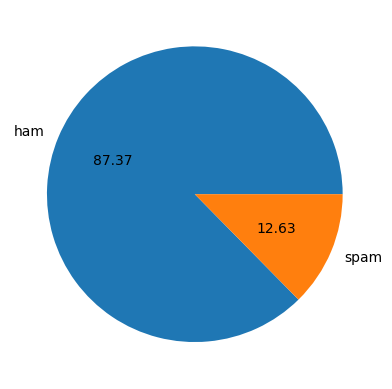

In [33]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [34]:
import nltk

In [43]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [37]:
df['num_characters']=df['text'].apply(len)

/tmp/ipykernel_2243/399031894.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_characters']=df['text'].apply(len)


In [44]:
df['num_sentences']=df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

/tmp/ipykernel_2243/1801296511.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_sentences']=df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))


In [46]:
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

/tmp/ipykernel_2243/1118471538.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))


In [47]:
df

,target,text,num_characters,num_sentences,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,2,24
1,0,Ok lar... Joking wif u oni...,29,2,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,2,37
3,0,U dun say so early hor... U c already then say...,49,1,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,1,15
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,4,35
5568,0,Will Ì_ b going to esplanade fr home?,37,1,9
5569,0,"Pity, * was in mood for that. So...any other s...",57,2,15
5570,0,The guy did some bitching but I acted like i'd...,125,1,27


In [49]:
df[['num_characters',	'num_sentences'	,'num_words']].describe()

,num_characters,num_sentences,num_words
count,5169.000000,5169.000000,5169.000000
mean,78.977945,1.965564,18.455794
std,58.236293,1.448541,13.324758
min,2.000000,1.000000,1.000000
25%,36.000000,1.000000,9.000000
50%,60.000000,1.000000,15.000000
75%,117.000000,2.000000,26.000000
max,910.000000,38.000000,220.000000


In [57]:
df[df['target']==1][['num_characters',	'num_sentences'	,'num_words']].describe()

,num_characters,num_sentences,num_words
count,653.000000,653.000000,653.000000
mean,137.891271,2.970904,27.667688
std,30.137753,1.488425,7.008418
min,13.000000,1.000000,2.000000
25%,132.000000,2.000000,25.000000
50%,149.000000,3.000000,29.000000
75%,157.000000,4.000000,32.000000
max,224.000000,9.000000,46.000000


In [58]:
df[df['target']==0][['num_characters',	'num_sentences'	,'num_words']].describe()

,num_characters,num_sentences,num_words
count,4516.000000,4516.000000,4516.000000
mean,70.459256,1.820195,17.123782
std,56.358207,1.383657,13.493970
min,2.000000,1.000000,1.000000
25%,34.000000,1.000000,8.000000
50%,52.000000,1.000000,13.000000
75%,90.000000,2.000000,22.000000
max,910.000000,38.000000,220.000000


<Axes: xlabel='num_words', ylabel='Count'>

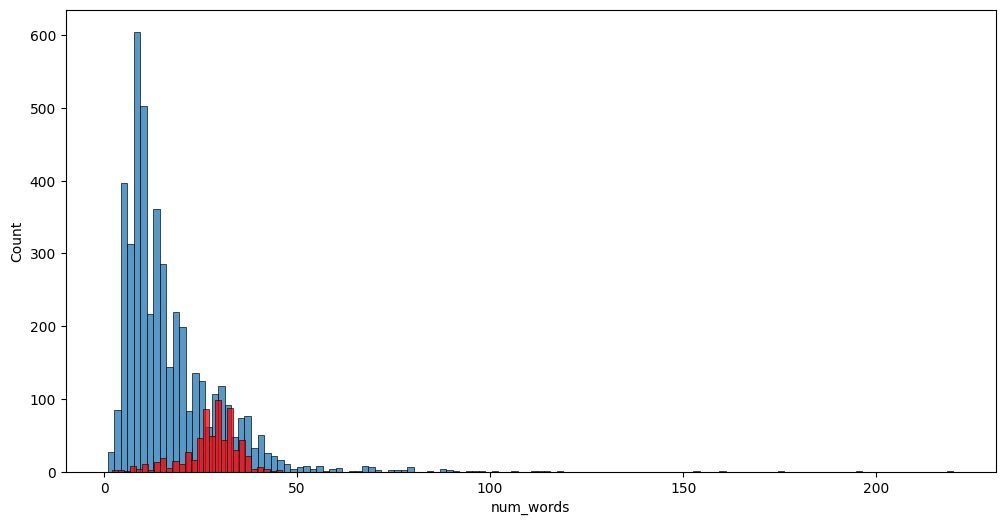

In [64]:
import seaborn as sns
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_words'])#not spam
sns.histplot(df[df['target']==1]['num_words'],color='red')#spam

<Axes: xlabel='num_characters', ylabel='Count'>

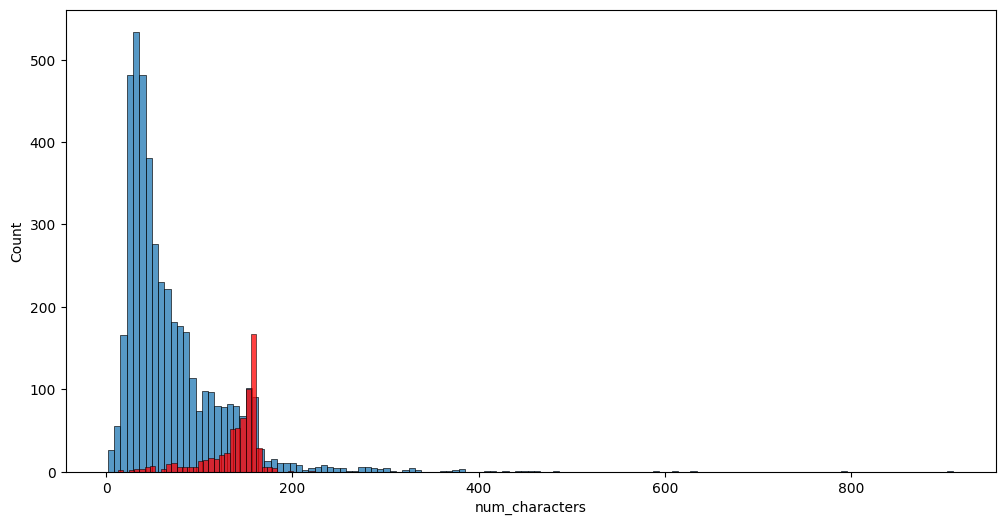

In [65]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_characters'])#not spam
sns.histplot(df[df['target']==1]['num_characters'],color='red')#spam

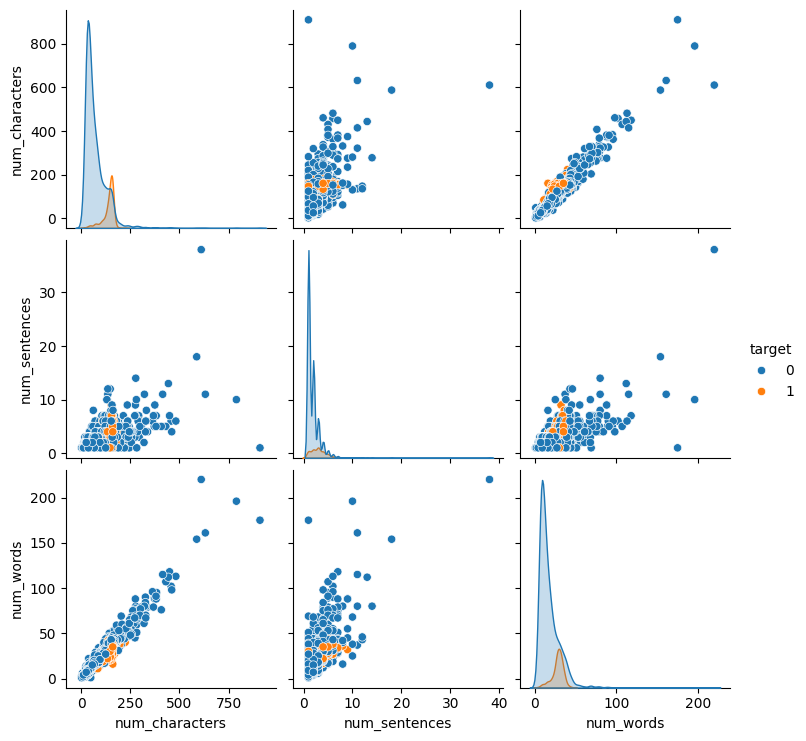

In [66]:
sns.pairplot(df,hue='target')

<Axes: >

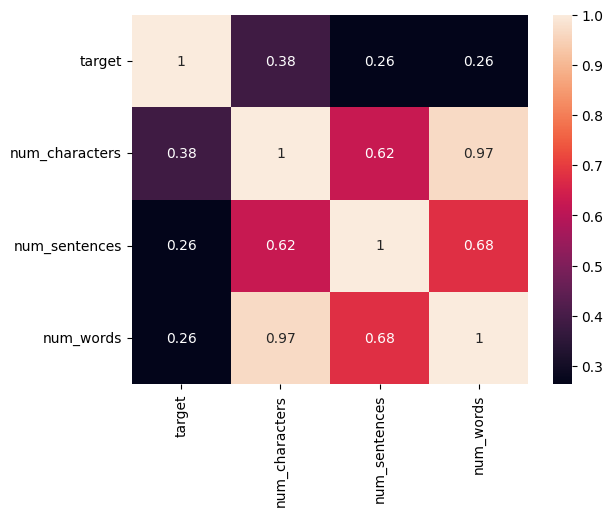

In [76]:
sns.heatmap(df[['target','num_characters',	'num_sentences'	,'num_words']].corr(),annot=True)

##3. Data Prerpcessing


*   Lowercase
*   Tokenization
*   Removing special characters
*   Removing stop words and punctuation
*   Stemming



In [81]:
import string

In [90]:
def transform_text(text):
  text= text.lower();
  text = nltk.word_tokenize(text)
  y=[]
  for i in text:
    if i.isalnum():
      y.append(i)
  text=y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)
  text=y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))

  return ' '.join(y)

In [94]:
transform_text('hi how are you sulav? wanna dance')

'hi sulav wan na danc'

In [95]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [97]:
df['transformed_text']=df['text'].apply(transform_text)

/tmp/ipykernel_2243/4139466366.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['transformed_text']=df['text'].apply(transform_text)


In [100]:
df.head(1)

,target,text,num_characters,num_sentences,num_words,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,2,24,go jurong point crazi avail bugi n great world...


In [103]:
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [104]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=' '))

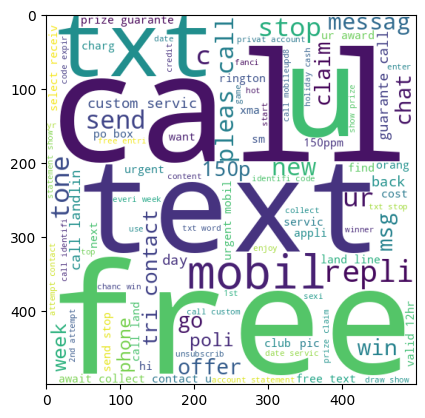

In [105]:
plt.imshow(spam_wc)

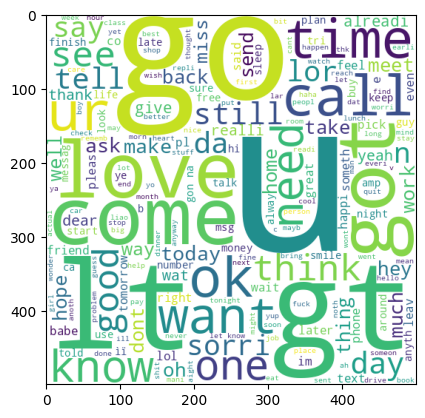

In [110]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=' '))
plt.imshow(ham_wc)

In [115]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
  for words in msg.split():
    spam_corpus.append(words)

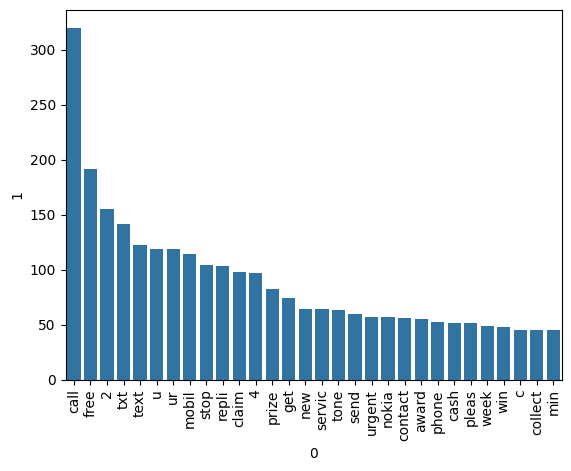

In [120]:
from collections import Counter
sns.barplot(
x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],
y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1]
)
plt.xticks(rotation='vertical')
plt.show()

In [123]:
ham_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
  for words in msg.split():
    ham_corpus.append(words)

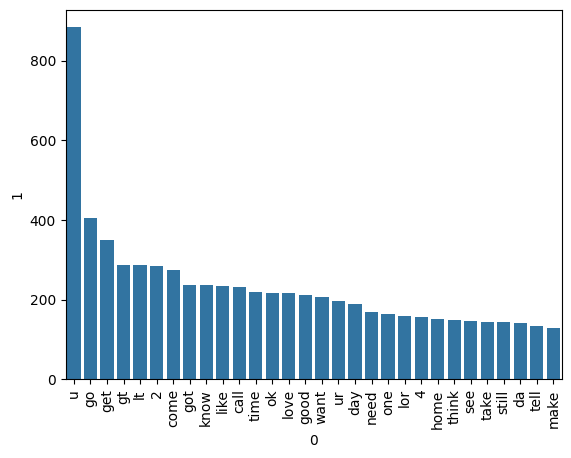

In [124]:
sns.barplot(
x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],
y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1]
)
plt.xticks(rotation='vertical')
plt.show()

##4. Model Building

In [141]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf=TfidfVectorizer()

In [142]:
# X=cv.fit_transform(df['transformed_text']).toarray()
X=tfidf.fit_transform(df['transformed_text']).toarray()

In [143]:
y=df['target'].values

In [144]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

xTrain,xTest,yTrain,yTest = train_test_split(X,y,test_size=0.2,random_state=2)

In [145]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [146]:
gnb.fit(xTrain,yTrain)
y_pred1=gnb.predict(xTest)
print(accuracy_score(yTest,y_pred1))
print(confusion_matrix(yTest,y_pred1))
print(precision_score(yTest,y_pred1))

0.8762088974854932
[[793 103]
 [ 25 113]]
0.5231481481481481


In [147]:
mnb.fit(xTrain,yTrain)
y_pred2=mnb.predict(xTest)
print(accuracy_score(yTest,y_pred2))
print(confusion_matrix(yTest,y_pred2))
print(precision_score(yTest,y_pred2))

0.9593810444874274
[[896   0]
 [ 42  96]]
1.0


In [140]:
bnb.fit(xTrain,yTrain)
y_pred3=mnb.predict(xTest)
print(accuracy_score(yTest,y_pred3))
print(confusion_matrix(yTest,y_pred3))
print(precision_score(yTest,y_pred3))

0.9642166344294004
[[871  25]
 [ 12 126]]
0.8344370860927153


In [ ]:
# tfidf-->mnb

In [151]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,BaggingClassifier,ExtraTreesClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier

In [152]:
svc=SVC(kernel='sigmoid',gamma=1.0)
knc=KNeighborsClassifier()
mnb=MultinomialNB()
dtc=DecisionTreeClassifier(max_depth=5)
lrc=LogisticRegression(solver='liblinear',penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

In [153]:
clfs = {
    'SVC': svc,
    'KN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'XGB': xgb
}

In [156]:
def train_classifier(clf,xTrain,xTest,yTrain,yTest):
  clf.fit(xTrain,yTrain)
  y_pred=clf.predict(xTest)
  acc=accuracy_score(yTest,y_pred)
  pre=precision_score(yTest,y_pred)
  return acc,pre

In [157]:
train_classifier(svc,xTrain,xTest,yTrain,yTest)

(0.9729206963249516, 0.9741379310344828)

In [159]:
acc_scores=[]
pre_scores=[]

for name,clf in clfs.items():
  accuracy,precision=train_classifier(clf,xTrain,xTest,yTrain,yTest)
  print("For: ",name)
  print("Accuracy: ",accuracy)
  print("Precision: ",precision)

  acc_scores.append(accuracy)
  pre_scores.append(precision)

For:  SVC
Accuracy:  0.9729206963249516
Precision:  0.9741379310344828
For:  KN
Accuracy:  0.9003868471953579
Precision:  1.0
For:  NB
Accuracy:  0.9593810444874274
Precision:  1.0
For:  DT
Accuracy:  0.9361702127659575
Precision:  0.8461538461538461
For:  LR
Accuracy:  0.9516441005802708
Precision:  0.94
For:  RF
Accuracy:  0.971953578336557
Precision:  1.0
For:  AdaBoost
Accuracy:  0.9245647969052224
Precision:  0.8409090909090909
For:  BgC
Accuracy:  0.9584139264990329
Precision:  0.8625954198473282
For:  ETC
Accuracy:  0.9729206963249516
Precision:  0.9824561403508771
For:  GBDT
Accuracy:  0.9526112185686654
Precision:  0.9238095238095239
For:  XGB
Accuracy:  0.9709864603481625
Precision:  0.9426229508196722


In [161]:
performance_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':acc_scores,'Precision':pre_scores}).sort_values('Precision',ascending=False)

In [162]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.900387,1.000000
2,NB,0.959381,1.000000
5,RF,0.971954,1.000000
8,ETC,0.972921,0.982456
0,SVC,0.972921,0.974138
10,XGB,0.970986,0.942623
4,LR,0.951644,0.940000
9,GBDT,0.952611,0.923810
7,BgC,0.958414,0.862595
3,DT,0.936170,0.846154


In [164]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(rfc,open('model.pkl','wb'))